EASY VISA DATA PREPROCESSING

This notebook implements preprocessing steps based on the comprehensive EDA findings and recommendations. 

We'll follow the evidence-based approach from the EDA report to ensure our preprocessing aligns with the data patterns discovered.
Based on the EDA report, we will:

1. **Handle Skewed Variables** - Log-transform `no_of_employees`, `yr_estab`, `prevailing_wage`
2. **Outlier Treatment** - IQR-capping for extreme - `no_of_employees`, `yr_estab`, `prevailing_wage` 
3. **Feature Engineering** - Create `total income `, `loan_income ratio`, `income_term`
4. **Feature Selection** - Keep high-signal features, evaluate low-signal ones
5. **Scaling** - StandardScaler for distance-based models
6. **Target Handling** - Classification approach with stratified splits

**Key EDA Evidence to Implement**

- **High-signal features**: `Credit_History`
- **Low-signal features**: `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term` `ApplicantIncome` (evaluate for removal)
- **Skewed variables**: `ApplicantIncome`, `CoApllicantIncome`, `Loan Amount` (log-transform)
- **Feature engineering**: Create `total_inocme` and `loan_income ratio`, `income_term`

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy as stat
import joblib
warnings.filterwarnings('ignore')

In [151]:
# Preprocessing libraries
from sklearn.preprocessing import StandardScaler, RobustScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

In [152]:
# Statistical libraries
from scipy import stats
from scipy.stats import zscore, skew

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [153]:
data = pd.read_csv("easy_visa_eda.csv")
data.head()

,Unnamed: 0,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,0
1,1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,1
2,2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,0
3,3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,0
4,4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,1


In [154]:
data.drop(columns=["Unnamed: 0"], inplace=True)

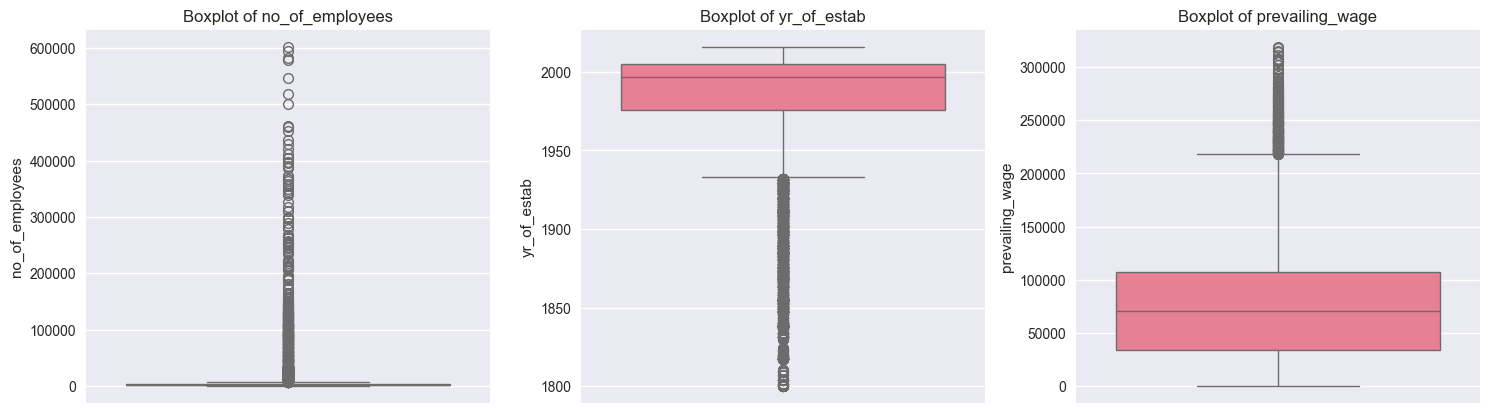

In [155]:
# Selecting numeric columns excluding 'Risk'
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

# Remove the dependent variable (Risk) from the list of numeric columns
numeric_columns.remove('case_status')  # Adjust the column name to match your dataset

# Plot the boxplots for all numeric columns (except Risk)
plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 3, i + 1)  # Adjust the grid size (rows, columns) as needed
    sns.boxplot(data=data, y=variable)
    plt.title(f'Boxplot of {variable}')
    plt.tight_layout()

plt.show()

In [156]:
data.head(1)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,0


# Finding Missing Data

In [157]:
# 1. Check for missing values (EDA showed no missing values)
print(" Missing Values:")
missing_values = data.isnull().sum()
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("No missing values found (as expected from EDA)")

 Missing Values:
No missing values found (as expected from EDA)


To Handle Outliers, some features need to be engineered.


Feature Enginering

In [158]:
data.head(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,0
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,1
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,0
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,0
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,1


In [159]:
# Years of Establishment

from datetime import datetime 

current_year = 2016
data["Age_of_est"] = current_year - data["yr_of_estab"]

In [160]:




# For the Annual Wages normalization
# Define conversion factors to yearly wage
conversion_map = {
    'Hour': 2080,       # 40 hrs × 52 weeks
    'Week': 52,
    'Month': 12,
    'Year': 1
}
# Create annual wage using .map()
data['annual_wage'] = data['prevailing_wage'] * data['unit_of_wage'].map(conversion_map)
data["hourly_wage"] = data['annual_wage'] / 2080
data["weekly_wage"] = data['annual_wage'] / 52
data["monthly_wage"] = data['annual_wage'] / 12



In [161]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,Age_of_est,annual_wage,hourly_wage,weekly_wage,monthly_wage
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,0,9,1231782.032,592.202900,23688.116000,102648.502667
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,1,14,83425.650,40.108486,1604.339423,6952.137500
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,0,8,122996.860,59.133106,2365.324231,10249.738333
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,0,119,83434.030,40.112514,1604.500577,6952.835833
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,1,11,149907.390,72.070861,2882.834423,12492.282500


# Handling Skewed Data

In [162]:
num_cols = data.select_dtypes(include=["number"]).columns
num_cols

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage', 'case_status',
       'Age_of_est', 'annual_wage', 'hourly_wage', 'weekly_wage',
       'monthly_wage'],
      dtype='object')

In [163]:
# Let's frist check for outliers and skewness of data

def num_vis_dist(data, feature):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.histplot(data[feature], kde=True, bins=30)
    plt.title(f"Histogram Distribution of {feature}")

    plt.subplot(1,2,2)
    sns.boxplot(x=data[feature])
    plt.title(f"Boxplot visualization of {feature} Skewness: {data[feature].skew():.2f}")

    plt.tight_layout()
    plt.show()

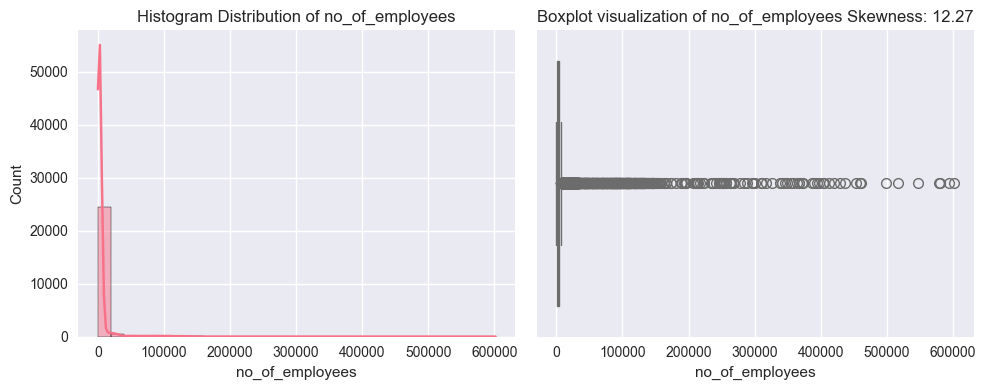

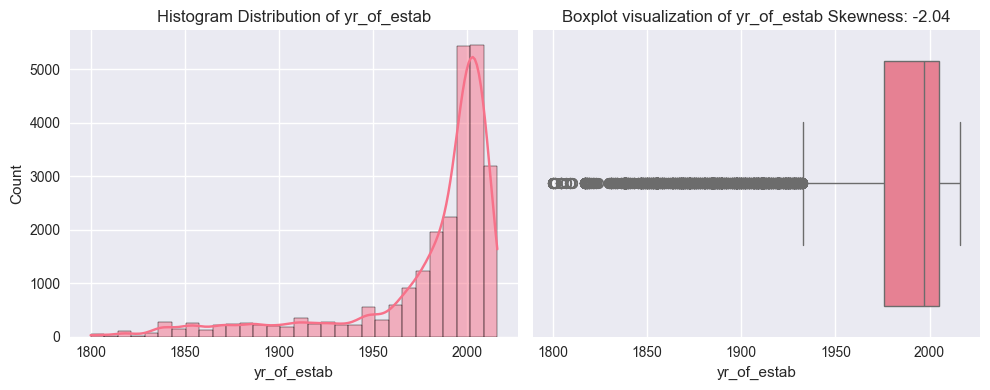

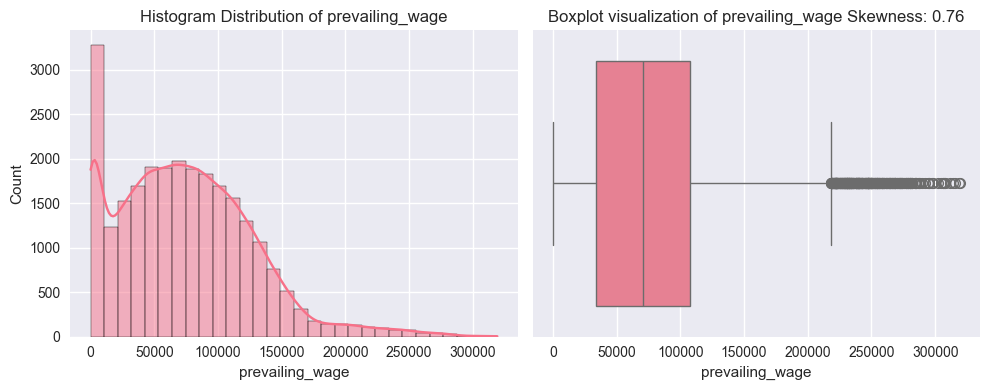

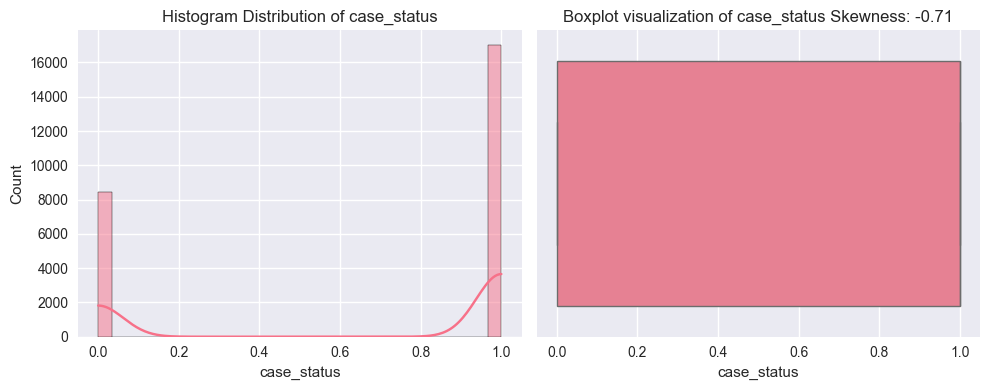

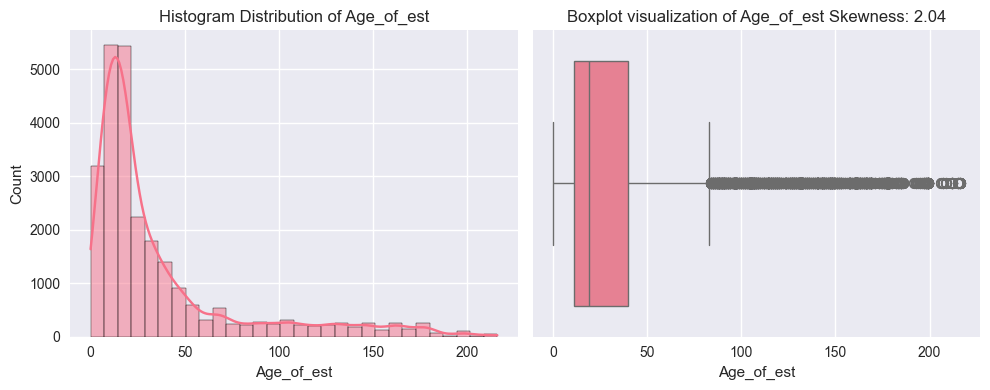

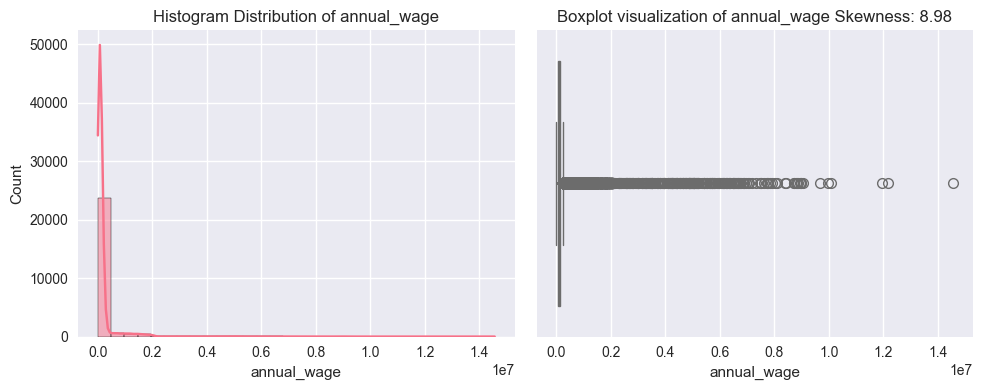

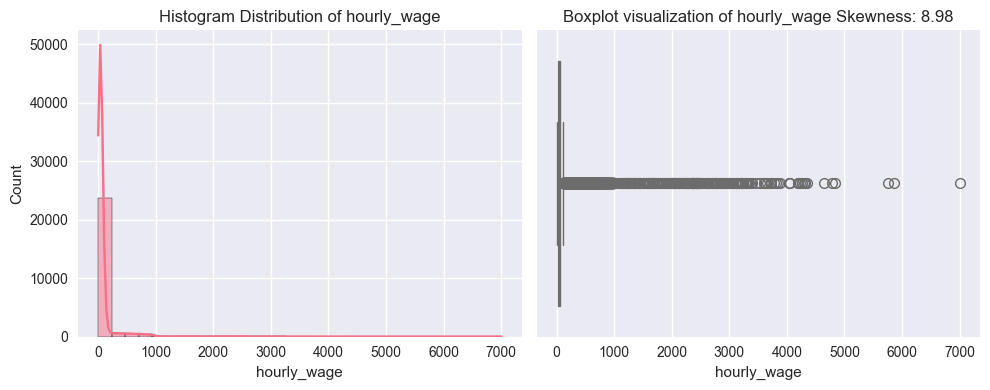

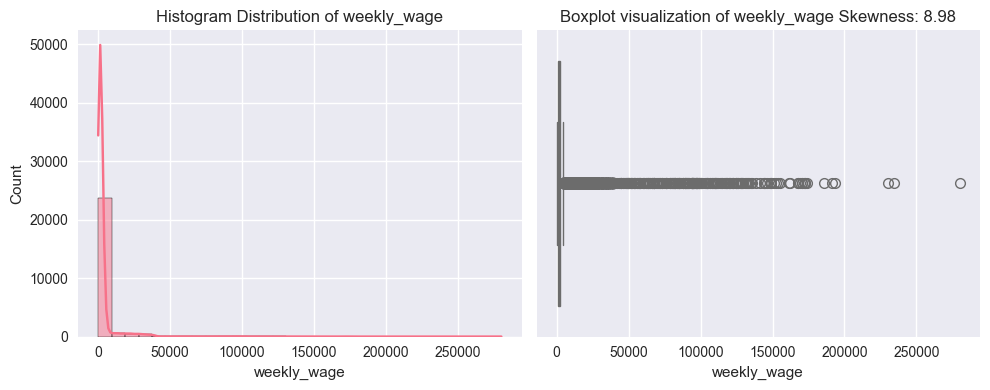

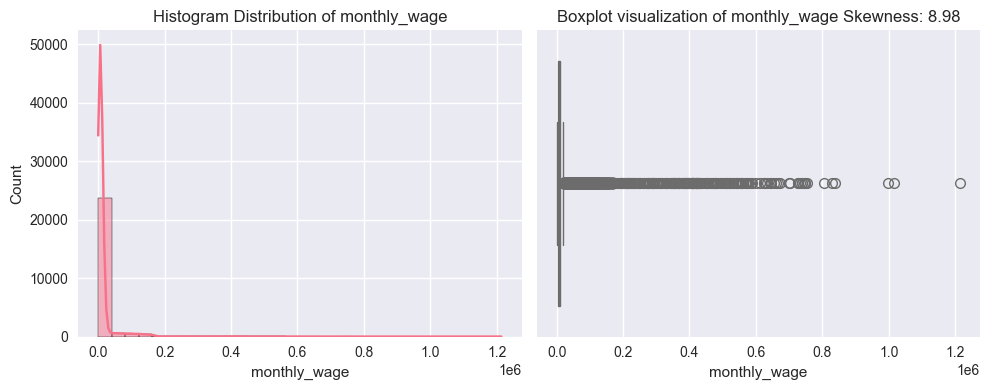

In [164]:
for feature in num_cols:
    num_vis_dist(data, feature)

We will Log_transform skewed data whic are applicantIncome, coapplicationIncome and LoanAmount

In [165]:
def Log_transform(column):
    """This function applies log transformation to a skewed column and plots the new distribution."""
    
    # Apply log transformation safely (handles zeros by adding 1)
    data[column] = np.log1p(data[column])
    
    # Plot the updated distribution
    plt.figure(figsize=(8,6))
    sns.histplot(data=data, x=column, kde=True, bins=30)
    plt.title(f"Log-Transformed Distribution of {column}\nSkewness: {data[column].skew():.2f}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [166]:
num_col = data.select_dtypes(include=["number"]).columns
num_col

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage', 'case_status',
       'Age_of_est', 'annual_wage', 'hourly_wage', 'weekly_wage',
       'monthly_wage'],
      dtype='object')

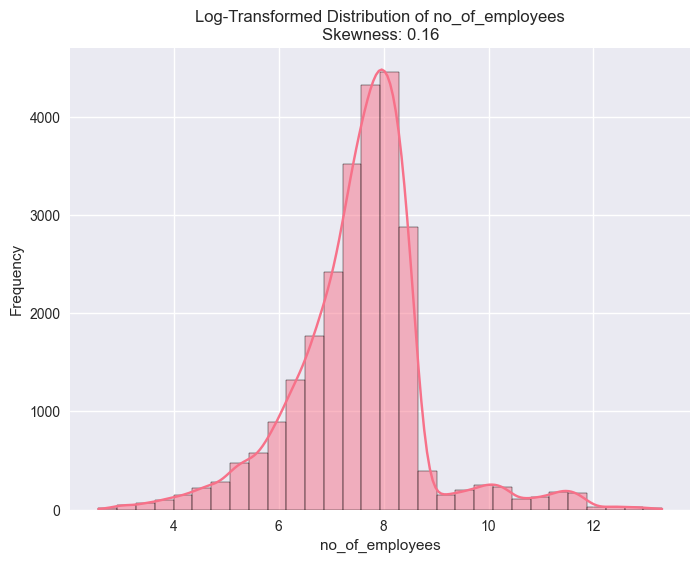

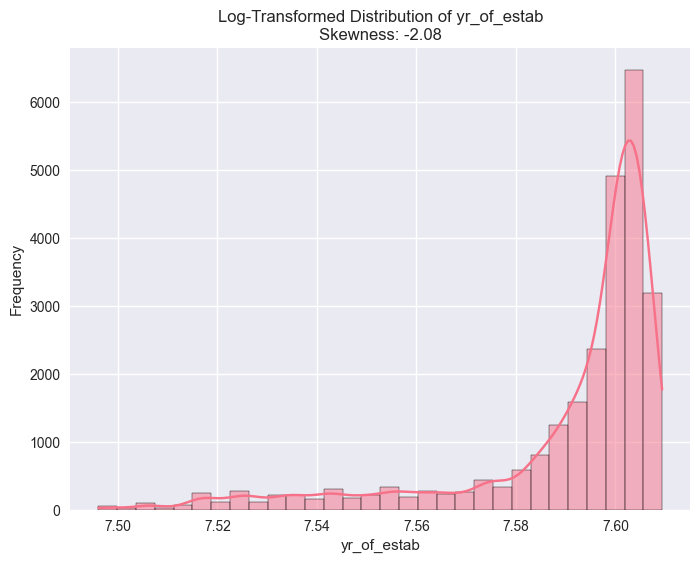

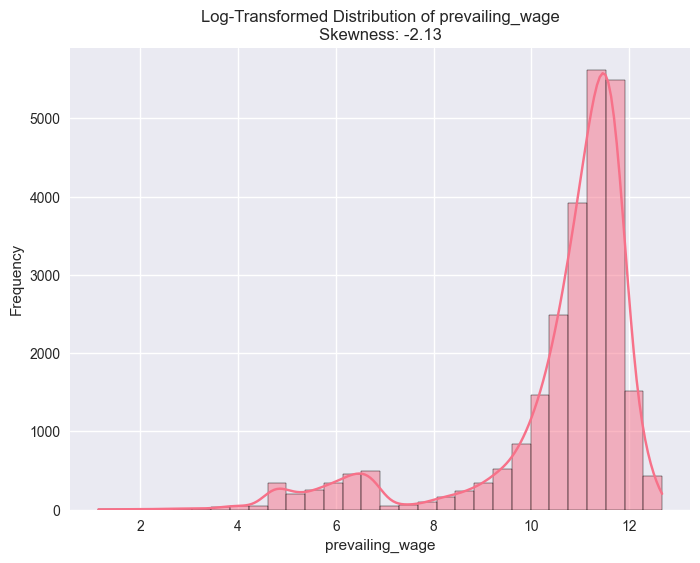

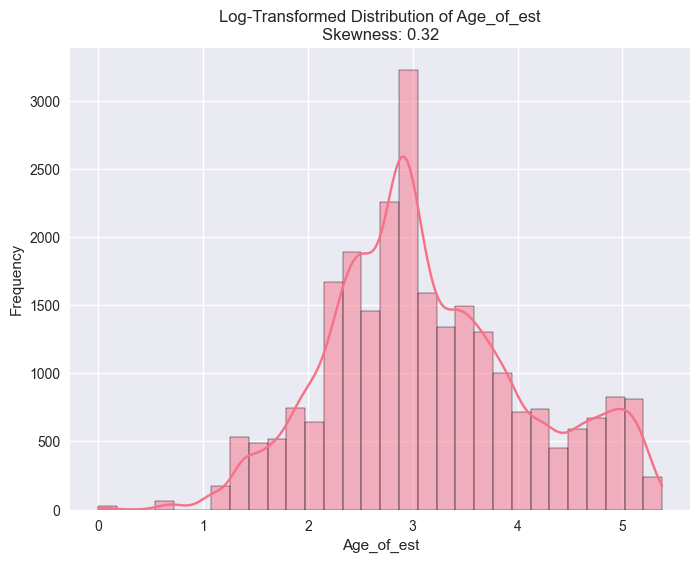

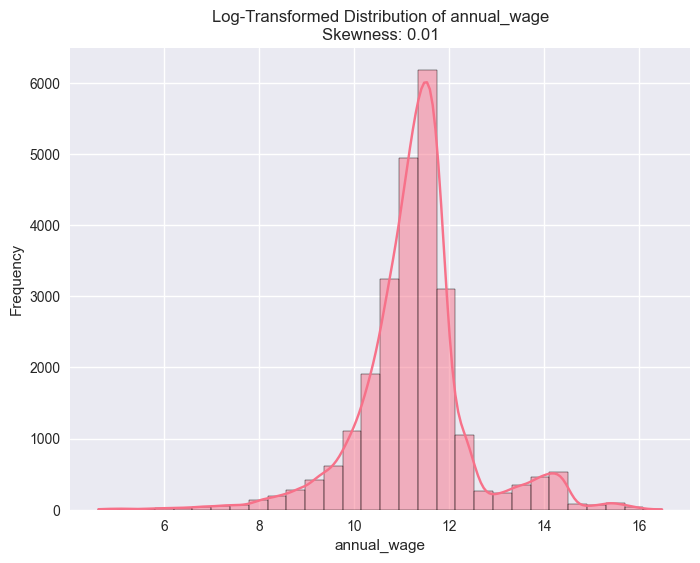

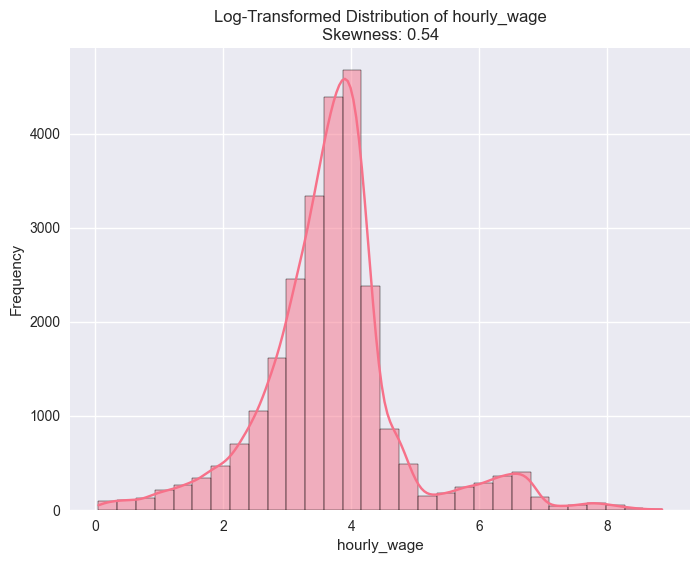

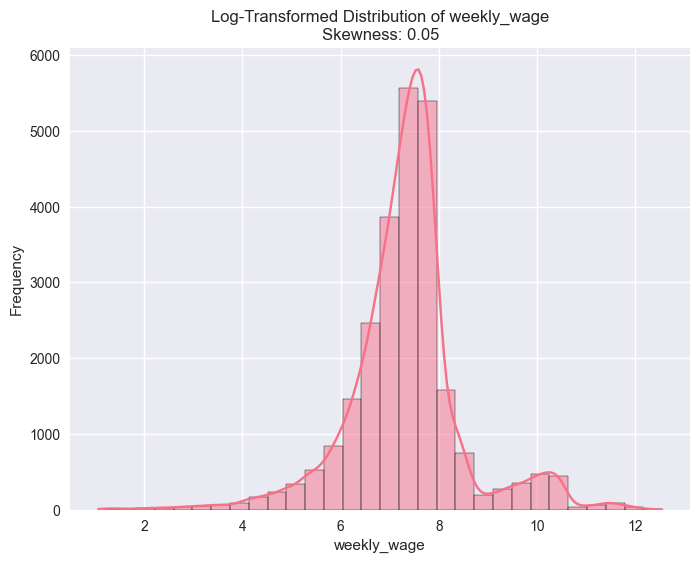

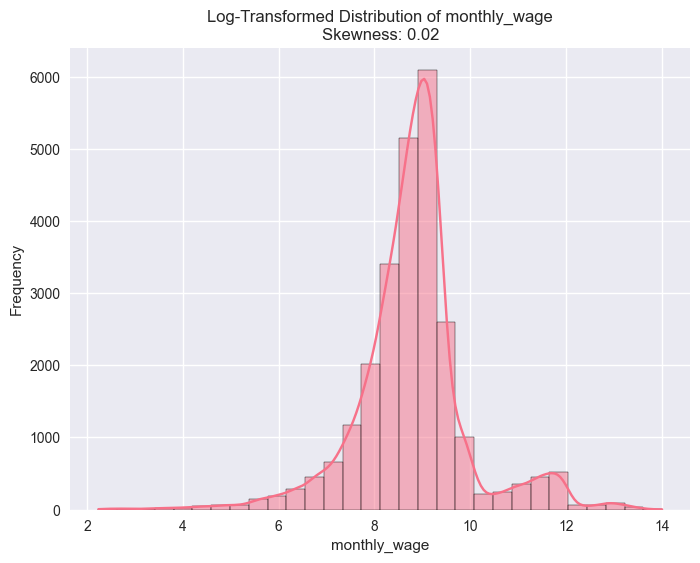

In [167]:
for col in ['no_of_employees', 'yr_of_estab', 'prevailing_wage',
       'Age_of_est', 'annual_wage', 'hourly_wage', 'weekly_wage',
       'monthly_wage']:
    Log_transform(col)


# ENCODING

In [168]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,Age_of_est,annual_wage,hourly_wage,weekly_wage,monthly_wage
0,EZYV01,Asia,High School,N,N,9.582869,7.604894,West,6.385536,Hour,Y,0,2.302585,14.023973,6.385536,10.072771,11.539076
1,EZYV02,Asia,Master's,Y,N,7.788626,7.602401,Northeast,11.331723,Year,Y,1,2.708050,11.331723,3.716215,7.381090,8.846948
2,EZYV03,Asia,Bachelor's,N,Y,10.702008,7.605392,West,11.719922,Year,Y,0,2.197225,11.719922,4.096561,7.769093,9.235105
3,EZYV04,Asia,Bachelor's,N,N,4.595120,7.548556,West,11.331824,Year,Y,0,4.787492,11.331824,3.716313,7.381191,8.847049
4,EZYV05,Africa,Master's,Y,N,6.987490,7.603898,South,11.917780,Year,Y,1,2.484907,11.917780,4.291430,7.966876,9.432946


In [169]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,Age_of_est,annual_wage,hourly_wage,weekly_wage,monthly_wage
0,EZYV01,Asia,High School,N,N,9.582869,7.604894,West,6.385536,Hour,Y,0,2.302585,14.023973,6.385536,10.072771,11.539076
1,EZYV02,Asia,Master's,Y,N,7.788626,7.602401,Northeast,11.331723,Year,Y,1,2.708050,11.331723,3.716215,7.381090,8.846948
2,EZYV03,Asia,Bachelor's,N,Y,10.702008,7.605392,West,11.719922,Year,Y,0,2.197225,11.719922,4.096561,7.769093,9.235105
3,EZYV04,Asia,Bachelor's,N,N,4.595120,7.548556,West,11.331824,Year,Y,0,4.787492,11.331824,3.716313,7.381191,8.847049
4,EZYV05,Africa,Master's,Y,N,6.987490,7.603898,South,11.917780,Year,Y,1,2.484907,11.917780,4.291430,7.966876,9.432946


In [170]:
data["continent"].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [171]:

"""
Step 2: Transformation (Encoding)
---------------------------------
Converts categorical variables into numeric using Label & One-Hot encoding.
"""
# Label Encoding (binary columns)
label_map = {
    'has_job_experience': {'Y': 1, 'N': 0},
    'requires_job_training': {'Y': 1, 'N': 0},
    'full_time_position': {'Y': 1, 'N': 0},
}
for col, mapping in label_map.items():
    if col in data.columns:
        data[col] = data[col].map(mapping)
# One-hot Encoding (multi-category columns)
onehot_cols = [
    'continent',
    'education_of_employee',
    'region_of_employment',
    'unit_of_wage'
]
data = pd.get_dummies(data, columns=onehot_cols, drop_first=False, dtype=int)
print("Transformation (encoding) complete.")
    

Transformation (encoding) complete.


In [172]:
data.head()
# print(data_processed.head())

,case_id,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,prevailing_wage,full_time_position,case_status,Age_of_est,annual_wage,...,education_of_employee_Master's,region_of_employment_Island,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Hour,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year
0,EZYV01,0,0,9.582869,7.604894,6.385536,1,0,2.302585,14.023973,...,0,0,0,0,0,1,1,0,0,0
1,EZYV02,1,0,7.788626,7.602401,11.331723,1,1,2.708050,11.331723,...,1,0,0,1,0,0,0,0,0,1
2,EZYV03,0,1,10.702008,7.605392,11.719922,1,0,2.197225,11.719922,...,0,0,0,0,0,1,0,0,0,1
3,EZYV04,0,0,4.595120,7.548556,11.331824,1,0,4.787492,11.331824,...,0,0,0,0,0,1,0,0,0,1
4,EZYV05,1,0,6.987490,7.603898,11.917780,1,1,2.484907,11.917780,...,1,0,0,0,1,0,0,0,0,1


Feature Selection

In [173]:

data.drop(columns=["case_id"], inplace=True)

In [174]:
data["case_status"].head(100)

0     0
1     1
2     0
3     0
4     1
     ..
95    1
96    0
97    1
98    0
99    0
Name: case_status, Length: 100, dtype: int64

In [175]:
# 4. Check correlation with target (EDA evidence)
print("\n4. Correlation with Quality (EDA Evidence):")
correlations = data.corr()['case_status'].sort_values(key=abs, ascending=False)
print("High-signal features (|correlation| > 0.15):")
high_signal = correlations[abs(correlations) > 0.2].drop('case_status')
for feature, corr in high_signal.items():
    print(f"  {feature}: {corr:.3f}")

print("\nLow-signal features (|correlation| < 0.1):")
low_signal = correlations[abs(correlations) < 0.1]
for feature, corr in low_signal.items():
    print(f"  {feature}: {corr:.3f}")


4. Correlation with Quality (EDA Evidence):
High-signal features (|correlation| > 0.15):
  education_of_employee_High School: -0.274
  unit_of_wage_Hour: -0.208

Low-signal features (|correlation| < 0.1):
  region_of_employment_Midwest: 0.084
  education_of_employee_Bachelor's: -0.080
  region_of_employment_West: -0.057
  region_of_employment_Northeast: -0.052
  continent_Asia: -0.044
  region_of_employment_South: 0.042
  continent_North America: -0.040
  continent_South America: -0.035
  no_of_employees: 0.026
  region_of_employment_Island: -0.017
  Age_of_est: -0.017
  continent_Africa: 0.017
  full_time_position: -0.013
  unit_of_wage_Week: -0.010
  yr_of_estab: 0.008
  requires_job_training: 0.008
  unit_of_wage_Month: -0.006
  continent_Oceania: -0.006


In [176]:
data["case_status"] = data["case_status"].map({0:  "Denied", 1:"Approved"})

In [177]:
data["case_status"].head()

0      Denied
1    Approved
2      Denied
3      Denied
4    Approved
Name: case_status, dtype: object

In [178]:
data.head()

,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,prevailing_wage,full_time_position,case_status,Age_of_est,annual_wage,hourly_wage,...,education_of_employee_Master's,region_of_employment_Island,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Hour,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year
0,0,0,9.582869,7.604894,6.385536,1,Denied,2.302585,14.023973,6.385536,...,0,0,0,0,0,1,1,0,0,0
1,1,0,7.788626,7.602401,11.331723,1,Approved,2.708050,11.331723,3.716215,...,1,0,0,1,0,0,0,0,0,1
2,0,1,10.702008,7.605392,11.719922,1,Denied,2.197225,11.719922,4.096561,...,0,0,0,0,0,1,0,0,0,1
3,0,0,4.595120,7.548556,11.331824,1,Denied,4.787492,11.331824,3.716313,...,0,0,0,0,0,1,0,0,0,1
4,1,0,6.987490,7.603898,11.917780,1,Approved,2.484907,11.917780,4.291430,...,1,0,0,0,1,0,0,0,0,1


In [181]:
data.drop(columns=["prevailing_wage"], inplace=True)

In [182]:
data.to_csv("easy_visa_preprocessed.csv")

## TRAINING MODEL

In [192]:

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pickle
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Data Splitting

1- Separating target feature from other features

In [184]:
X = data.drop("case_status", axis=1)
y = data["case_status"]

2- Splitting Data into train and test data

In [186]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

3- Choosing a Model

In [187]:
model = RandomForestClassifier(random_state=42)


4- Training/ Fitting the Model

In [188]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


5- Making Predictions

In [189]:
y_pred = model.predict(X_test)


Evaluating the Model for Classification

In [197]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4314  805]
 [1316 1209]]


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7225274725274725
[[4314  805]
 [1316 1209]]
              precision    recall  f1-score   support

    Approved       0.77      0.84      0.80      5119
      Denied       0.60      0.48      0.53      2525

    accuracy                           0.72      7644
   macro avg       0.68      0.66      0.67      7644
weighted avg       0.71      0.72      0.71      7644



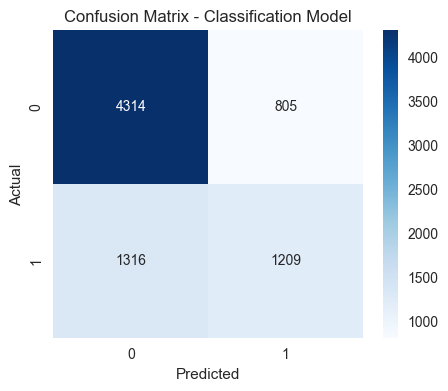

In [202]:
# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - Classification Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()